# Multi-panel scenes and live serving

- `grid()` composes several `Scene3D`s into one subplot window, optionally with **linked cameras** (orbit
  one, they all move). It returns a `pyvista.Plotter`, so we screenshot the plotter directly.
- `serve()` / `jupyter()` hand the scene to PyVista's **trame** integration for a genuinely interactive,
  streaming view in a notebook — the alternative to the frozen `screenshot`/`export_html` snapshot.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from digitalearth.base.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()
from digitalearth.three_d import grid
from pyramids.dataset import Dataset

## `grid()` — several scenes, linked cameras

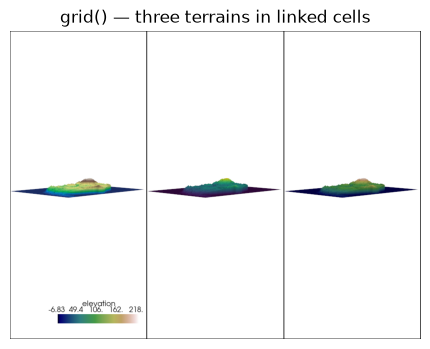

In [2]:
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))

def panel(cmap):
    s = Scene3D(off_screen=True)
    s.terrain(dem, z_exaggeration=8.0, cmap=cmap)
    return s

plotter = grid([panel('terrain'), panel('viridis'), panel('gist_earth')],
               shape=(1, 3), link=True, off_screen=True)
img = plotter.screenshot(return_img=True)
show_image(img, 'grid() — three terrains in linked cells')
plotter.close()

## `serve()` / `jupyter()` — a live trame view

In a running Jupyter session, `scene.serve()` returns a trame widget you can orbit, zoom and pick in real
time; `scene.jupyter('static')` switches PyVista's notebook backend to the screenshot used throughout this
gallery. Here we only construct the handle (its live canvas needs a kernel/browser).

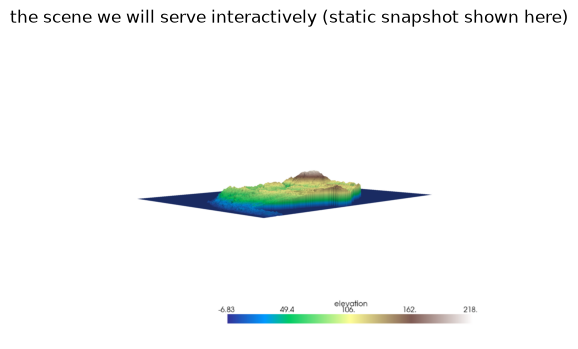

serve() returned: Widget — interactive in a live notebook


In [3]:
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, cmap='terrain')
show(scene, 'the scene we will serve interactively (static snapshot shown here)')
widget = scene.serve(mode='client')     # a trame widget — pan/zoom/pick live in a running notebook
print('serve() returned:', type(widget).__name__, '— interactive in a live notebook')
scene.close()